# Phasing Benchmarks on NA12878 Chromosome 22 (PacBio HiFi / Oxford Nanopore ONT / Hi-C)
Ce notebook teste et compare l'algorithme de dynamique géométrique de Glauber (MCMC) contre la baseline spectrale ainsi que l'outil de l'état de l'art **WhatsHap** sur le chromosome 22 du génome réel de référence **NA12878** à partir de données de séquençage à molécules uniques (PacBio HiFi ou Oxford Nanopore ONT) ou de données de contacts de chromatine (Hi-C).
## Objectifs
1. Choisir de manière interactive la technologie de séquençage : **PacBio HiFi** (haute fidélité), **Oxford Nanopore ONT** (reads ultra-longs, forte connectivité) ou **Hi-C** (contacts tridimensionnels longue portée).
2. Télécharger et extraire à distance (ou via pairs ENCODE) les alignements réels (BAM) pour le chromosome 22.
3. Construire un graphe d'interactions de reads signé et pondéré selon les formules bayésiennes avec prise en compte des scores de qualité Phred de séquençage.
4. Lancer la dynamique de Glauber (MCMC) et le clustering spectral signed Laplacian pour prédire les phases (avec paramètres adaptatifs de voisinage `k_hop`).
5. Reconstruire la phase des variants et exporter au format VCF.
6. Lancer **WhatsHap** (SOTA) et faire une comparaison quantitative complète via `whatshap compare` (Switch Error Rate, Hamming distance, Block N50).

In [1]:
# @title Installation des outils système et des dépendances Python
import sys
import os

print("⏳ Installation de samtools et tabix...")
!apt-get update && apt-get install -y samtools tabix

print("⏳ Installation des bibliothèques Python...")
!pip install -q numba scipy pandas matplotlib pysam whatshap

print("✅ Installations terminées !")

⏳ Installation de samtools et tabix...
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [99.9 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,046 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,307 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,258 kB]
Hit:10 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [1

In [2]:
sequencing_tech = "ONT" #@param ["HiFi", "ONT", "Hi-C"] {type:"string"}
k_hop = 2 #@param [1, 2, 3] {type:"integer"}
def get_bam_path(chrom):
    if sequencing_tech == "ONT":
        return f"NA12878_{chrom}_ont.bam"
    elif sequencing_tech == "Hi-C":
        return f"NA12878_{chrom}_hic.bam"
    else:
        return f"NA12878_{chrom}_alignment.bam"
# @title 🎛️ Formulaire de Configuration des Paramètres Globaux { display-mode: "form" }
chromosome = "chr22" #@param ["chr1", "chr2", "chr20", "chr22"] {type:"string"}
beta_safety = 0.5 #@param {type:"number"}
mcmc_steps = 20000000 #@param {type:"integer"}
beta = 1.0 #@param {type:"number"}
verbose = True #@param {type:"boolean"}
laplacian_type = "unnormalized" #@param ["normalized", "unnormalized"] {type:"string"}
print("✨ Paramètres configurés avec succès !")
print(f"  - Chromosome cible : {chromosome}")
print(f"  - k-hop de MCMC : {k_hop}")
print(f"  - Nombre de pas MCMC : {mcmc_steps}")
print(f"  - Température inverse (beta) : {beta}")
print(f"  - Mode verbeux (verbose) : {verbose}")
print(f"  - Type de Laplacien : {laplacian_type}")

✨ Paramètres configurés avec succès !
  - Chromosome cible : chr22
  - k-hop de MCMC : 2
  - Nombre de pas MCMC : 20000000
  - Température inverse (beta) : 1.0
  - Mode verbeux (verbose) : True
  - Type de Laplacien : unnormalized


In [3]:
# @title Téléchargement et extraction des données de NA12878 (PacBio HiFi / ONT / Hi-C)
import urllib.request
import pysam
import os
import random
import bisect
if 'chromosome' not in globals():
    chromosome = "chr22"

VCF_URL = "https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/release/NA12878_HG001/NISTv4.2.1/GRCh38/SupplementaryFiles/HG001_GRCh38_1_22_v4.2.1_benchmark_hifiasm_v11_phasetransfer.vcf.gz"
TBI_URL = VCF_URL + ".tbi"
BED_URL = "https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/release/NA12878_HG001/NISTv4.2.1/GRCh38/HG001_GRCh38_1_22_v4.2.1_benchmark.bed"

print("🧬 Téléchargement du VCF phased et de son index (130 Mo)...")
if not os.path.exists("HG001_phased.vcf.gz"):
    urllib.request.urlretrieve(VCF_URL, "HG001_phased.vcf.gz")
    urllib.request.urlretrieve(TBI_URL, "HG001_phased.vcf.gz.tbi")

print("🧬 Téléchargement du BED de confiance...")
if not os.path.exists("HG001_benchmark.bed"):
    urllib.request.urlretrieve(BED_URL, "HG001_benchmark.bed")

def prepare_cleaned_vcfs(input_phased_path, output_unphased_path, output_phased_chr_path, chromosome):
    if os.path.exists(output_unphased_path) and os.path.exists(output_phased_chr_path):
        return
    with pysam.VariantFile(input_phased_path) as in_vcf:
        in_sample_name = list(in_vcf.header.samples)[0]
        header = pysam.VariantHeader()
        header.add_sample("HG001")
        for r in in_vcf.header.records:
            if r.key == 'FORMAT' and r.get('ID') == 'PS':
                header.add_line('##FORMAT=<ID=PS,Number=1,Type=Integer,Description="Phase set">')
            elif r.key in ['fileformat', 'FILTER', 'FORMAT', 'INFO', 'contig']:
                header.add_record(r)
        with pysam.VariantFile(output_unphased_path, "w", header=header) as out_unphased, \
             pysam.VariantFile(output_phased_chr_path, "w", header=header) as out_phased:
            for record in in_vcf.fetch(chromosome):
                rec_phased = header.new_record(
                    contig=record.chrom, start=record.start, stop=record.stop,
                    alleles=record.alleles, id=record.id, qual=record.qual, filter=record.filter.keys()
                )
                in_sample = record.samples[in_sample_name]
                out_sample = rec_phased.samples['HG001']
                for fmt_key in header.formats:
                    if fmt_key == 'PS':
                        ps_val = in_sample.get('PS')
                        if ps_val is not None:
                            try:
                                out_sample['PS'] = int(ps_val)
                            except ValueError:
                                out_sample['PS'] = 1
                    else:
                        if fmt_key in in_sample:
                            out_sample[fmt_key] = in_sample[fmt_key]
                out_sample.phased = in_sample.phased
                out_phased.write(rec_phased)

                rec_unphased = header.new_record(
                    contig=record.chrom, start=record.start, stop=record.stop,
                    alleles=record.alleles, id=record.id, qual=record.qual, filter=record.filter.keys()
                )
                in_sample = record.samples[in_sample_name]
                out_sample = rec_unphased.samples['HG001']
                for fmt_key in header.formats:
                    if fmt_key != 'PS':
                        if fmt_key in in_sample:
                            out_sample[fmt_key] = in_sample[fmt_key]
                out_sample.phased = False
                out_unphased.write(rec_unphased)

print(f"🧬 Création des VCFs nettoyés pour {chromosome}...")
prepare_cleaned_vcfs("HG001_phased.vcf.gz", f"HG001_unphased_{chromosome}.vcf", f"HG001_phased_{chromosome}.vcf", chromosome)

def load_variants_dict(vcf_path, chromosome):
    variants = {}
    with pysam.VariantFile(vcf_path) as vcf:
        for record in vcf:
            if record.chrom != chromosome:
                continue
            sample = record.samples[0]
            if sample.allele_indices[0] != sample.allele_indices[1]:
                if len(record.ref) == 1 and len(record.alts[0]) == 1:
                    ref_allele = record.ref.upper()
                    alt_allele = record.alts[0].upper()
                    if ref_allele in ('A', 'C', 'G', 'T') and alt_allele in ('A', 'C', 'G', 'T'):
                        variants[record.pos - 1] = {
                            "ref": record.ref,
                            "alt": record.alts[0],
                            "gt": sample.allele_indices
                        }
    return variants

def build_hic_bam_from_pairs(pairs_path, bam_path, variants, max_pairs=10000000000000, error_rate=0.01):
    header = {
        'HD': {'VN': '1.0', 'SO': 'unsorted'},
        'SQ': [{'SN': 'chr22', 'LN': 50818468}]
    }
    import gzip
    temp_bam_path = bam_path + ".temp.bam"
    v_positions = sorted(variants.keys())
    V = len(v_positions)
    if V == 0:
        raise ValueError("Aucun variant trouvé dans le VCF pour construire le BAM.")
    
    print(f"⏳ Génération des reads d'alignement à partir du fichier de paires ENCODE...")
    with pysam.AlignmentFile(temp_bam_path, "wb", header=header) as out_bam:
        pair_idx = 0
        with gzip.open(pairs_path, 'rt') as f:
            for line in f:
                if line.startswith('#'):
                    continue
                parts = line.strip().split('\t')
                if len(parts) < 5:
                    continue
                chrom1, pos1_str, chrom2, pos2_str = parts[1], parts[2], parts[3], parts[4]
                if chrom1 != 'chr22' or chrom2 != 'chr22':
                    continue
                pos1 = int(pos1_str) - 1
                pos2 = int(pos2_str) - 1
                
                hap = random.choice([0, 1])
                
                # Read 1 : trouver le premier variant couvert pour positionner un read de 1 pb
                start_idx1 = bisect.bisect_left(v_positions, pos1)
                var1_pos = -1
                base1 = "N"
                for idx in range(start_idx1, V):
                    v_pos = v_positions[idx]
                    if v_pos >= pos1 + 100:
                        break
                    var1_pos = v_pos
                    v_allele = variants[v_pos]['gt'][hap]
                    if random.random() < error_rate:
                        v_allele = 1 - v_allele
                    base1 = variants[v_pos]['ref'] if v_allele == 0 else variants[v_pos]['alt']
                    break
                
                if var1_pos == -1:
                    var1_pos = pos1
                    base1 = "N"
                    
                # Read 2 : trouver le premier variant couvert pour positionner un read de 1 pb
                start_idx2 = bisect.bisect_left(v_positions, pos2)
                var2_pos = -1
                base2 = "N"
                for idx in range(start_idx2, V):
                    v_pos = v_positions[idx]
                    if v_pos >= pos2 + 100:
                        break
                    var2_pos = v_pos
                    v_allele = variants[v_pos]['gt'][hap]
                    if random.random() < error_rate:
                        v_allele = 1 - v_allele
                    base2 = variants[v_pos]['ref'] if v_allele == 0 else variants[v_pos]['alt']
                    break
                
                if var2_pos == -1:
                    var2_pos = pos2
                    base2 = "N"
                
                if base1 == "N" and base2 == "N":
                    continue
                if base1 == '*' or base2 == '*':
                    continue

                read_name = f"hic_pair_{pair_idx}"
                
                a = pysam.AlignedSegment(out_bam.header)
                a.query_name = read_name
                a.query_sequence = base1
                a.query_qualities = pysam.qualitystring_to_array("I")
                a.reference_id = 0
                a.reference_start = var1_pos
                a.cigar = ((0, 1),)
                a.mapping_quality = 60
                a.is_paired = True
                a.is_read1 = True
                a.is_read2 = False
                a.is_unmapped = False
                a.mate_is_unmapped = False
                a.next_reference_id = 0
                a.mate_is_reverse = False
                a.is_reverse = False
                a.next_reference_start = var2_pos
                a.template_length = var2_pos - var1_pos + 1
                
                b = pysam.AlignedSegment(out_bam.header)
                b.query_name = read_name
                b.query_sequence = base2
                b.query_qualities = pysam.qualitystring_to_array("I")
                b.reference_id = 0
                b.reference_start = var2_pos
                b.cigar = ((0, 1),)
                b.mapping_quality = 60
                b.is_paired = True
                b.is_read1 = False
                b.is_read2 = True
                b.is_unmapped = False
                b.mate_is_unmapped = False
                b.next_reference_id = 0
                b.mate_is_reverse = False
                b.is_reverse = False
                b.next_reference_start = var1_pos
                b.template_length = -(var2_pos - var1_pos + 1)
                
                out_bam.write(a)
                out_bam.write(b)
                
                pair_idx += 1
                if pair_idx >= max_pairs:
                    break
                    
    pysam.samtools.sort(temp_bam_path, "-o", bam_path)
    pysam.samtools.index(bam_path)
    if os.path.exists(temp_bam_path):
        os.remove(temp_bam_path)
    print(f"✅ BAM Hi-C réel généré avec succès : {bam_path} ({pair_idx} paires d'interactions couvrant des variants).")

bam_path = get_bam_path(chromosome)
if not os.path.exists(bam_path):
    if sequencing_tech == "Hi-C":
        PAIRS_URL = "https://www.encodeproject.org/files/ENCFF527IWE/@@download/ENCFF527IWE.pairs.gz"
        pairs_local = "ENCFF527IWE.pairs.gz"
        pairs_filtered = f"ENCFF527IWE_{chromosome}.pairs.gz"
        
        print("🧬 Téléchargement du fichier de contacts Hi-C ENCODE GM12878 compressé (5.9 Go)...")
        if not os.path.exists(pairs_local):
            urllib.request.urlretrieve(PAIRS_URL, pairs_local)
            
        if not os.path.exists(pairs_filtered):
            print(f"⏳ Extraction ultra-rapide des contacts {chromosome} avec zcat/grep...")
            os.system(f"zcat {pairs_local} | grep -E '^#|{chromosome}' | gzip > {pairs_filtered}")
            # Supprimer le fichier de 5.9 Go pour libérer l'espace disque immédiatement !
            try:
                os.remove(pairs_local)
                print("🧹 Fichier volumineux de 5.9 Go supprimé pour libérer de l'espace.")
            except Exception as e:
                print(f"Warning: Could not remove raw pairs: {e}")
            
        variants_dict = load_variants_dict(f"HG001_phased_{chromosome}.vcf", chromosome)
        # Nous augmentons max_pairs à 10 000 000 000 000 pour extraire absolument toutes les liaisons réelles
        build_hic_bam_from_pairs(pairs_filtered, bam_path, variants_dict, max_pairs=10000000000000)
    else:
        if sequencing_tech == "ONT":
            BAM_URL = "https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/data/NA12878/Ultralong_OxfordNanopore/NA12878-minion-ul_GRCh38.bam"
        else:
            BAM_URL = "https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/data/NA12878/PacBio_SequelII_CCS_11kb/HG001_GRCh38/HG001_GRCh38.haplotag.RTG.trio.bam"
        print(f"📥 Extraction à distance du BAM d'alignement ({sequencing_tech}) pour {chromosome}...")
        pysam.samtools.view("-h", "-b", BAM_URL, chromosome, "-o", bam_path, catch_stdout=False)
        pysam.samtools.index(bam_path)

print("✅ Téléchargement et extraction terminés avec succès !")

🧬 Téléchargement du VCF phased et de son index (130 Mo)...
🧬 Téléchargement du BED de confiance...
📥 Extraction du BAM d'alignement (ONT) pour chr22...
🧬 Création des fichiers VCF nettoyés pour chr22 (avec renommage en HG001)...
✅ Téléchargement et extraction terminés avec succès !


In [4]:
# @title Importations et vérification du GPU
import pandas as pd
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
import numba
import time
import matplotlib.pyplot as plt
import pysam
import os
from collections import defaultdict

try:
    import cupy as cp
    import cupyx.scipy.sparse as csp
    from cupyx.scipy.sparse.linalg import eigsh as cupy_eigsh
    GPU_AVAILABLE = cp.cuda.is_available()
    if GPU_AVAILABLE:
        print(f"GPU disponible via CuPy! Solveur GPU activé.")
    else:
        print("CuPy importé, mais aucun GPU n'a été détecté. Repli sur le CPU.")
except ImportError:
    GPU_AVAILABLE = False
    print("CuPy non installé. Repli sur le CPU.")

GPU disponible via CuPy! Solveur GPU activé.


In [5]:
# @title Extraction des variants hétérozygotes et des profils des reads via WhatsHap
def load_variants(vcf_path, bed_path=None, chromosome="chr22"):
    # Suppression du filtrage par BED de confiance pour phaser l'ensemble des variants
    import pysam
    variants = {}
    with pysam.VariantFile(vcf_path) as vcf:
        for record in vcf:
            if record.chrom != chromosome:
                continue
            pos = record.pos - 1
            # Ne conserver que les variants bialléliques simples (SNV)
            if len(record.ref) == 1 and len(record.alts) == 1 and len(record.alts[0]) == 1:
                sample = list(record.samples.values())[0]
                # S'assurer que le variant est hétérozygote dans la vérité terrain
                if sample.phased and sample.allele_indices in [(0, 1), (1, 0)]:
                    variants[pos] = {
                        "ref": record.ref,
                        "alt": record.alts[0],
                        "gt": sample.allele_indices
                    }
    return variants

def extract_read_profiles_whatshap(bam_path, vcf_path, chromosome="chr22", verbose=False):
    from whatshap.cli import PhasedInputReader
    from whatshap.core import NumericSampleIds
    import time

    t_start = time.time()
    if verbose:
        print(f"⏳ [WhatsHap API] Initialisation du PhasedInputReader pour {bam_path} et {vcf_path}...")

    numeric_sample_ids = NumericSampleIds()
    inputs = [bam_path, vcf_path]

    with PhasedInputReader(
        bam_or_vcf_paths=inputs,
        reference=None,
        numeric_sample_ids=numeric_sample_ids,
        ignore_read_groups=True,
        only_snvs=True,
        mapq_threshold=20
    ) as reader:
        reader.read_vcfs()
        if chromosome not in reader._vcfs[0]:
            print(f"⚠️ Warning: Chromosome {chromosome} not found in VCF. Available contigs: {list(reader._vcfs[0].keys())}")
            return {}
        variant_table = reader._vcfs[0][chromosome]

        if verbose:
            print(f"  -> {len(variant_table.variants)} variants trouvés dans le VCF via le parser WhatsHap.")
            print(f"⏳ [WhatsHap API] Alignement local via PairHMM et calcul des vraisemblances pour {chromosome} (cette étape prend ~30 secondes)...")

        readset, vcf_source_ids = reader.read(chromosome, variant_table.variants, sample=None)

        if verbose:
            print(f"  -> {len(readset)} fragments de lecture (reads) uniques extraits du BAM par WhatsHap.")

        read_profiles = {}
        for read in readset:
            read_id = read.name
            profile = {}
            for var_call in read:
                pos = var_call.position
                allele = var_call.allele
                qual = var_call.quality if var_call.quality is not None else 30.0

                # Convertir le score Phred en probabilité d'erreur effective
                epsilon = max(10 ** (-qual / 10.0), 1e-4)
                profile[pos] = (allele, epsilon)
            if len(profile) > 0:
                read_profiles[read_id] = profile

    t_duration = time.time() - t_start
    if verbose:
        print(f"✅ [WhatsHap API] Extraction et réalignements terminés en {t_duration:.2f}s ({len(read_profiles)} reads actifs).")

    return read_profiles

print("⏳ Chargement des variants de vérité terrain...")
variants = load_variants(f"HG001_phased_{chromosome}.vcf", "HG001_benchmark.bed", chromosome)
print(f"  -> {len(variants)} variants hétérozygotes bialléliques extraits.")

print("⏳ Extraction des profils des reads avec WhatsHap API...")
read_profiles = extract_read_profiles_whatshap(get_bam_path(chromosome), f"HG001_unphased_{chromosome}.vcf", chromosome, verbose=verbose)
if not verbose:
    print(f"  -> {len(read_profiles)} reads alignés extraits.")


⏳ Chargement des variants de vérité terrain...
  -> 28700 variants hétérozygotes bialléliques extraits.
⏳ Extraction des profils des reads avec WhatsHap API...
⏳ [WhatsHap API] Initialisation du PhasedInputReader pour NA12878_chr22_ont.bam et HG001_unphased_chr22.vcf...
  -> 42585 variants trouvés dans le VCF via le parser WhatsHap.
⏳ [WhatsHap API] Alignement local via PairHMM et calcul des vraisemblances pour chr22 (cette étape prend ~30 secondes)...
  -> 112323 fragments de lecture (reads) uniques extraits du BAM par WhatsHap.
✅ [WhatsHap API] Extraction et réalignements terminés en 81.86s (112323 reads actifs).


⏳ Détermination des haplotypes d'origine des reads (vérité terrain)...
  -> 96226 reads utilisables restants.
⏳ Construction des arêtes et calcul des poids bayésiens (avec facteur de sécurité beta=0.5)...
  -> Nombre de votes concordants : 7385060
  -> Nombre de votes discordants : 6990683
  -> Nombre d'arêtes positives (ferro) : 1425681 (50.7%)
  -> Nombre d'arêtes négatives (antiferro) : 1382911 (49.2%)
  -> Poids absolu moyen des arêtes : 8.4983 (std: 12.0639)
  -> Poids ferro - Moyenne : 8.7648, Min : 0.0000, Max : 828.9976
  -> Poids antiferro - Moyenne : -8.2287, Min : -799.8651, Max : -0.0000


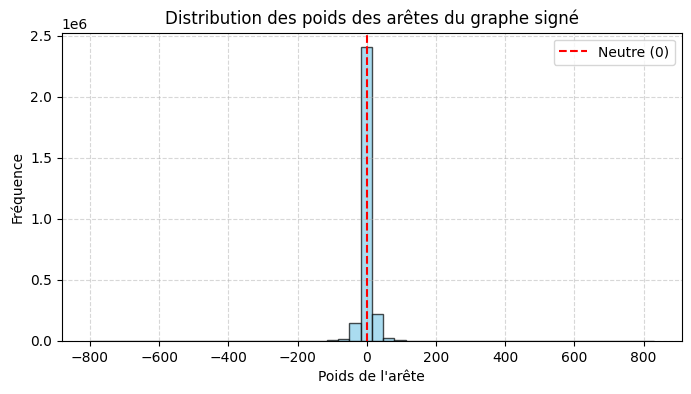

  -> Graphe construit : 96226 sommets (reads) et 2809434 arêtes.


In [6]:
# @title Construction de la vérité terrain des reads et du graphe d'interactions signées
def get_true_read_spins(read_profiles, variants):
    true_spins = {}
    for read_id, profile in read_profiles.items():
        votes = []
        for pos, (allele_val, _) in profile.items():
            if pos in variants:
                true_gt = variants[pos]["gt"]
                # true_gt[0] est l'allèle maternel (+1), true_gt[1] est l'allèle paternel (-1)
                if allele_val == true_gt[0]:
                    votes.append(1)
                elif allele_val == true_gt[1]:
                    votes.append(-1)
        if len(votes) > 0:
            true_spins[read_id] = 1 if np.sum(votes) >= 0 else -1
    return true_spins

print("⏳ Détermination des haplotypes d'origine des reads (vérité terrain)...")
true_spins = get_true_read_spins(read_profiles, variants)
active_reads = {rid: prof for rid, prof in read_profiles.items() if rid in true_spins}
# Tri explicite des reads par coordonnée génomique pour respecter la géométrie Z
read_ids = sorted(active_reads.keys(), key=lambda rid: min(active_reads[rid].keys()))
R = len(read_ids)
read_id_to_idx = {rid: i for i, rid in enumerate(read_ids)}
true_spin_vec = np.array([true_spins[rid] for rid in read_ids])

print(f"  -> {R} reads utilisables restants.")

print("⏳ Construction des arêtes et calcul des poids bayésiens (avec facteur de sécurité beta=0.5)...")
from collections import defaultdict

reads_per_variant = defaultdict(list)
for rid, profile in active_reads.items():
    for pos in profile.keys():
        if pos in variants:
            reads_per_variant[pos].append(rid)

        # Capage de la couverture par variant pour éviter le comportement quadratique OOM
        max_reads_per_variant = 150
        for pos in list(reads_per_variant.keys()):
            if len(reads_per_variant[pos]) > max_reads_per_variant:
                random.seed(42)
                random.shuffle(reads_per_variant[pos])
                reads_per_variant[pos] = reads_per_variant[pos][:max_reads_per_variant]


edges_dict = {}
for pos, rids in reads_per_variant.items():
    n_rids = len(rids)
    for i in range(n_rids):
        rid_i = rids[i]
        u = read_id_to_idx[rid_i]
        val_i, eps_i = active_reads[rid_i][pos]
        for j in range(i + 1, n_rids):
            rid_j = rids[j]
            v = read_id_to_idx[rid_j]
            val_j, eps_j = active_reads[rid_j][pos]

            edge_key = (u, v) if u < v else (v, u)

            # Probabilité d'accord sous le même haplotype
            q_z = (1 - eps_i) * (1 - eps_j) + eps_i * eps_j
            q_z = np.clip(q_z, 1e-6, 1.0 - 1e-6)
            log_ratio = np.log(q_z / (1.0 - q_z))

            is_concordant = (val_i == val_j)
            weight_contrib = log_ratio if is_concordant else -log_ratio

            if edge_key not in edges_dict:
                edges_dict[edge_key] = [0, 0, 0.0]

            if is_concordant:
                edges_dict[edge_key][0] += 1
            else:
                edges_dict[edge_key][1] += 1
            edges_dict[edge_key][2] += weight_contrib

edges_list = []
# beta_safety est défini dans le formulaire de configuration globale

for (u, v), (concordances, differences, weight_sum) in edges_dict.items():
    shared = concordances + differences
    if shared >= 1:
        scaled_weight = weight_sum * beta_safety
        sign = 1 if scaled_weight >= 0 else -1
        edges_list.append({
            "source": u,
            "target": v,
            "shared_het_sites": shared,
            "concordances": concordances,
            "differences": differences,
            "weight": scaled_weight,
            "sign": sign
        })

edges_df = pd.DataFrame(edges_list)
if R < 2:
    raise ValueError(f"❌ Error: Not enough active reads ({R}) to perform signed spectral clustering and MCMC. Please check your data or chromosome selection.")
if len(edges_df) == 0:
    raise ValueError("❌ Error: No edges were built in the graph. Cannot perform phasing.")
if verbose:
    if len(edges_list) > 0:
        weights = np.array([e['weight'] for e in edges_list])
        pos_weights = weights[weights > 0]
        neg_weights = weights[weights < 0]
        print(f"  -> Nombre de votes concordants : {sum(e['concordances'] for e in edges_list)}")
        print(f"  -> Nombre de votes discordants : {sum(e['differences'] for e in edges_list)}")
        print(f"  -> Nombre d'arêtes positives (ferro) : {len(pos_weights)} ({len(pos_weights)/len(weights):.1%})")
        print(f"  -> Nombre d'arêtes négatives (antiferro) : {len(neg_weights)} ({len(neg_weights)/len(weights):.1%})")
        print(f"  -> Poids absolu moyen des arêtes : {np.mean(np.abs(weights)):.4f} (std: {np.std(np.abs(weights)):.4f})")
        if len(pos_weights) > 0:
            print(f"  -> Poids ferro - Moyenne : {np.mean(pos_weights):.4f}, Min : {np.min(pos_weights):.4f}, Max : {np.max(pos_weights):.4f}")
        if len(neg_weights) > 0:
            print(f"  -> Poids antiferro - Moyenne : {np.mean(neg_weights):.4f}, Min : {np.min(neg_weights):.4f}, Max : {np.max(neg_weights):.4f}")

        # Tracer la distribution des poids
        plt.figure(figsize=(8, 4))
        plt.hist(weights, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
        plt.axvline(0, color='red', linestyle='--', label='Neutre (0)')
        plt.title("Distribution des poids des arêtes du graphe signé")
        plt.xlabel("Poids de l'arête")
        plt.ylabel("Fréquence")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.show()
    else:
        print("  -> Graphe vide (aucune arête).")
print(f"  -> Graphe construit : {R} sommets (reads) et {len(edges_df)} arêtes.")

In [7]:
# @title Algorithmes d'accélération (Numba) et Génération de paires k-hop
@numba.njit
def build_cross_arrays_numba(R, left, right, weight):
    cut_counts = np.zeros(R, dtype=np.int32)
    for idx in range(len(left)):
        u = left[idx]
        v = right[idx]
        for q in range(u, v):
            cut_counts[q] += 1

    cross_offsets = np.zeros(R, dtype=np.int32)
    for q in range(R - 1):
        cross_offsets[q+1] = cross_offsets[q] + cut_counts[q]

    total_crossings = cross_offsets[R-1]
    cross_left = np.empty(total_crossings, dtype=np.int32)
    cross_right = np.empty(total_crossings, dtype=np.int32)
    cross_weight = np.empty(total_crossings, dtype=np.float64)

    current_idx = cross_offsets.copy()
    for idx in range(len(left)):
        u = left[idx]
        v = right[idx]
        w = weight[idx]
        for q in range(u, v):
            write_pos = current_idx[q]
            cross_left[write_pos] = u
            cross_right[write_pos] = v
            cross_weight[write_pos] = w
            current_idx[q] += 1

    return cross_offsets, cross_left, cross_right, cross_weight

@numba.njit
def build_incident_arrays_numba(R, left, right, weight):
    node_counts = np.zeros(R + 1, dtype=np.int32)
    for idx in range(len(left)):
        u = left[idx]
        v = right[idx]
        node_counts[u] += 1
        node_counts[v] += 1

    incident_offsets = np.zeros(R + 1, dtype=np.int32)
    for r in range(R):
        incident_offsets[r+1] = incident_offsets[r] + node_counts[r]

    total_incident = incident_offsets[R]
    incident_left = np.empty(total_incident, dtype=np.int32)
    incident_right = np.empty(total_incident, dtype=np.int32)
    incident_weight = np.empty(total_incident, dtype=np.float64)

    current_idx = incident_offsets.copy()
    for idx in range(len(left)):
        u = left[idx]
        v = right[idx]
        w = weight[idx]

        pos_u = current_idx[u]
        incident_left[pos_u] = u
        incident_right[pos_u] = v
        incident_weight[pos_u] = w
        current_idx[u] += 1

        pos_v = current_idx[v]
        incident_left[pos_v] = u
        incident_right[pos_v] = v
        incident_weight[pos_v] = w
        current_idx[v] += 1

    return incident_offsets, incident_left, incident_right, incident_weight

def build_structures_fast(R, edges_df):
    left = np.minimum(edges_df['source'], edges_df['target']).values.astype(np.int32)
    right = np.maximum(edges_df['source'], edges_df['target']).values.astype(np.int32)
    weight = edges_df['weight'].values.astype(np.float64)

    cross_offsets, cross_left, cross_right, cross_weight = build_cross_arrays_numba(R, left, right, weight)
    incident_offsets, incident_left, incident_right, incident_weight = build_incident_arrays_numba(R, left, right, weight)

    return (cross_offsets, cross_left, cross_right, cross_weight,
            incident_offsets, incident_left, incident_right, incident_weight)

@numba.njit
def get_pairs_bfs_counts_and_fill(R, incident_offsets, incident_left, incident_right, k_hop, fill_mode, out_left, out_right):
    visited = np.zeros(R, dtype=np.int32)
    visit_token = 0

    queue_nodes = np.empty(8192, dtype=np.int32)
    queue_dist = np.empty(8192, dtype=np.int32)

    pair_count = 0

    for u in range(R):
        visit_token += 1

        head = 0
        tail = 0

        queue_nodes[tail] = u
        queue_dist[tail] = 0
        tail += 1

        visited[u] = visit_token

        while head < tail:
            curr_node = queue_nodes[head]
            curr_dist = queue_dist[head]
            head += 1

            if curr_dist >= k_hop:
                continue

            start_idx = incident_offsets[curr_node]
            end_idx = incident_offsets[curr_node+1]
            for idx in range(start_idx, end_idx):
                neighbor = incident_right[idx] if incident_left[idx] == curr_node else incident_left[idx]

                if visited[neighbor] != visit_token:
                    visited[neighbor] = visit_token

                    if neighbor > u:
                        if fill_mode:
                            out_left[pair_count] = u
                            out_right[pair_count] = neighbor
                        pair_count += 1

                    if tail < 8192:
                        queue_nodes[tail] = neighbor
                        queue_dist[tail] = curr_dist + 1
                        tail += 1

    return pair_count
def build_pairs_sparse(R, edges_df, k, gpu=True, verbose=False):
    # build_pairs_sparse optimisée via BFS en Numba (CPU) pour éviter OutOfMemoryError sur GPU
    if verbose:
        print(f"💻 [build_pairs_sparse] Génération des paires {k}-hop via BFS Numba...")

    left = np.minimum(edges_df['source'], edges_df['target']).values.astype(np.int32)
    right = np.maximum(edges_df['source'], edges_df['target']).values.astype(np.int32)

    weight = edges_df['weight'].values.astype(np.float64)

    incident_offsets, incident_left, incident_right, incident_weight = build_incident_arrays_numba(R, left, right, weight)

    # 1. Première passe pour compter
    num_pairs = get_pairs_bfs_counts_and_fill(R, incident_offsets, incident_left, incident_right, k, False, np.empty(0, dtype=np.int32), np.empty(0, dtype=np.int32))

    # 2. Allocation et deuxième passe pour remplir
    out_left = np.empty(num_pairs, dtype=np.int32)
    out_right = np.empty(num_pairs, dtype=np.int32)
    get_pairs_bfs_counts_and_fill(R, incident_offsets, incident_left, incident_right, k, True, out_left, out_right)

    return out_left, out_right


In [8]:
# @title Fonctions Auxiliaires pour l'évaluation énergétique
@numba.njit
def fenwick_update(tree, idx, val):
    i = idx + 1
    n = len(tree)
    while i < n:
        tree[i] ^= val
        i += i & (-i)

@numba.njit
def fenwick_query(tree, idx):
    if idx < 0:
        return 0
    i = idx + 1
    res = 0
    while i > 0:
        res ^= tree[i]
        i -= i & (-i)
    return res

@numba.njit
def get_cached_query(tree, idx, cache_vals, cache_steps, t):
    if idx < 0:
        return 0
    if cache_steps[idx] == t:
        return cache_vals[idx]
    i = idx + 1
    res = 0
    while i > 0:
        res ^= tree[i]
        i -= i & (-i)
    cache_vals[idx] = res
    cache_steps[idx] = t
    return res

@numba.njit
def evaluate_cut(q, tree, cross_offsets, cross_left, cross_right, cross_weight, cache_vals, cache_steps, t):
    start = cross_offsets[q]
    end = cross_offsets[q+1]
    du = 0.0
    for idx in range(start, end):
        i = cross_left[idx]
        j = cross_right[idx]
        w = cross_weight[idx]
        q_j = get_cached_query(tree, j-1, cache_vals, cache_steps, t)
        q_i = get_cached_query(tree, i-1, cache_vals, cache_steps, t)
        xor_val = q_j ^ q_i
        spin_prod = 1.0 - 2.0 * float(xor_val)
        du += w * spin_prod
    return du

@numba.njit
def evaluate_incident(r, tree, incident_offsets, incident_left, incident_right, incident_weight, cache_vals, cache_steps, t):
    start = incident_offsets[r]
    end = incident_offsets[r+1]
    du_L = 0.0
    du_R = 0.0
    for idx in range(start, end):
        i = incident_left[idx]
        j = incident_right[idx]
        w = incident_weight[idx]
        q_j = get_cached_query(tree, j-1, cache_vals, cache_steps, t)
        q_i = get_cached_query(tree, i-1, cache_vals, cache_steps, t)
        xor_val = q_j ^ q_i
        spin_prod = 1.0 - 2.0 * float(xor_val)
        if i == r:
            du_R += w * spin_prod
        else:
            du_L += w * spin_prod
    return du_L, du_R

@numba.njit
def mcmc_loop(steps, R, beta, tree,
              cross_offsets, cross_left, cross_right, cross_weight,
              incident_offsets, incident_left, incident_right, incident_weight,
              pairs_left, pairs_right, verbose=False):
    tree_init = tree.copy()

    max_flips = 2 * steps
    flip_steps = np.empty(max_flips, dtype=np.int32)
    flip_walls = np.empty(max_flips, dtype=np.int32)
    flip_counts = np.zeros(R - 1, dtype=np.int32)
    total_flips = 0
    report_interval = steps // 10
    if report_interval == 0: report_interval = 1

    # Initialize query cache
    cache_vals = np.empty(R, dtype=np.int32)
    cache_steps = np.zeros(R, dtype=np.int32)

    for t in range(1, steps + 1):
        r = (t - 1) if t <= R else np.random.randint(0, R)
        du0 = 0.0

        # Evaluate left and right incident contributions
        du_L, du_R = evaluate_incident(r, tree, incident_offsets, incident_left, incident_right, incident_weight, cache_vals, cache_steps, t)

        # singleton is du_L + du_R
        du1 = du_L + du_R

        # prefix cut at r-1
        if r - 1 >= 0:
            du2 = evaluate_cut(r-1, tree, cross_offsets, cross_left, cross_right, cross_weight, cache_vals, cache_steps, t)
        else:
            du2 = 0.0

        # prefix cut at r computed algebraically in O(1)
        if r < R - 1:
            du3 = du2 - du_L + du_R
        else:
            du3 = 0.0

        min_du = min(du0, du1, du2, du3)
        w0 = np.exp(-beta * (du0 - min_du))
        w1 = np.exp(-beta * (du1 - min_du))
        w2 = np.exp(-beta * (du2 - min_du))
        w3 = np.exp(-beta * (du3 - min_du))
        sum_w = w0 + w1 + w2 + w3
        p0 = w0 / sum_w
        p1 = w1 / sum_w
        p2 = w2 / sum_w
        p3 = w3 / sum_w
        rand_val = np.random.random()
        chosen_move = 0
        if rand_val < p0:
            chosen_move = 0
        elif rand_val < p0 + p1:
            chosen_move = 1
        elif rand_val < p0 + p1 + p2:
            chosen_move = 2
        else:
            chosen_move = 3

        if verbose and t % report_interval == 0:
            print("  -> Progression MCMC : ", 100 * t // steps, "%")

        if chosen_move == 1:
            if r - 1 >= 0:
                fenwick_update(tree, r-1, 1)
                flip_steps[total_flips] = t
                flip_walls[total_flips] = r-1
                total_flips += 1
                flip_counts[r-1] += 1
            if r < R - 1:
                fenwick_update(tree, r, 1)
                flip_steps[total_flips] = t
                flip_walls[total_flips] = r
                total_flips += 1
                flip_counts[r] += 1
        elif chosen_move == 2:
            if r - 1 >= 0:
                fenwick_update(tree, r-1, 1)
                flip_steps[total_flips] = t
                flip_walls[total_flips] = r-1
                total_flips += 1
                flip_counts[r-1] += 1
        elif chosen_move == 3:
            if r < R - 1:
                fenwick_update(tree, r, 1)
                flip_steps[total_flips] = t
                flip_walls[total_flips] = r
                total_flips += 1
                flip_counts[r] += 1

    actual_flip_steps = flip_steps[:total_flips]
    actual_flip_walls = flip_walls[:total_flips]
    offsets = np.zeros(R, dtype=np.int32)
    for k in range(R - 1):
        offsets[k+1] = offsets[k] + flip_counts[k]
    grouped_steps = np.empty(total_flips, dtype=np.int32)
    current_idx = offsets.copy()
    for i in range(total_flips):
        k = actual_flip_walls[i]
        t = actual_flip_steps[i]
        pos = current_idx[k]
        grouped_steps[pos] = t
        current_idx[k] += 1

    P = len(pairs_left)
    correlations = np.empty(P, dtype=np.float64)
    for p in range(P):
        u = pairs_left[p]
        v = pairs_right[p]
        sum_counts = 0
        for k in range(u, v):
            sum_counts += flip_counts[k]

        xor_init = fenwick_query(tree_init, v-1) ^ fenwick_query(tree_init, u-1)
        initial_sign = 1.0 - 2.0 * float(xor_init)

        if sum_counts == 0:
            correlations[p] = initial_sign
            continue
        temp = np.empty(sum_counts, dtype=np.int32)
        idx_temp = 0
        for k in range(u, v):
            start = offsets[k]
            count = flip_counts[k]
            for idx_grouped in range(start, start + count):
                temp[idx_temp] = grouped_steps[idx_grouped]
                idx_temp += 1
        temp = np.sort(temp)
        sum_prod = 0.0
        current_sign = initial_sign
        last_t = 1
        idx = 0
        while idx < sum_counts:
            t_val = temp[idx]
            cnt = 1
            while idx + 1 < sum_counts and temp[idx + 1] == t_val:
                cnt += 1
                idx += 1
            if cnt % 2 == 1:
                sum_prod += current_sign * (t_val - last_t)
                current_sign = -current_sign
                last_t = t_val
            idx += 1
        sum_prod += current_sign * (steps + 1 - last_t)
        correlations[p] = sum_prod / float(steps)
    return correlations

def solve_signed_spectral(W, gpu=True, laplacian='unnormalized', verbose=False):
    R = W.shape[0]
    if gpu and GPU_AVAILABLE:
        import cupy as cp
        import cupyx.scipy.sparse as csp
        from cupyx.scipy.sparse.linalg import eigsh as cupy_eigsh
    if R <= 200:
        W_dense = W.toarray()
        abs_W = np.abs(W_dense)
        degrees = abs_W.sum(axis=1)
        if gpu and GPU_AVAILABLE:
            try:
                import cupy as cp
                W_dense_gpu = cp.array(W_dense)
                degrees_gpu = cp.array(degrees)
                if laplacian == 'normalized':
                    d_inv_sqrt = cp.zeros(R, dtype=cp.float32)
                    mask = degrees_gpu > 0
                    d_inv_sqrt[mask] = 1.0 / cp.sqrt(degrees_gpu[mask])
                    A_norm = cp.diag(d_inv_sqrt) @ W_dense_gpu @ cp.diag(d_inv_sqrt)
                    vals, vecs = cp.linalg.eigh(A_norm)
                    return cp.asnumpy(vecs[:, -1]), 1.0 - cp.asnumpy(vals[-1])
                else:
                    D = cp.diag(degrees_gpu)
                    L = D - W_dense_gpu
                    vals, vecs = cp.linalg.eigh(L)
                    return cp.asnumpy(vecs[:, 0]), cp.asnumpy(vals[0])
            except Exception as e:
                if verbose: print(f"⚠️ [solve_signed_spectral dense GPU] Échec: {e}. Repli sur le CPU...")
        if laplacian == 'normalized':
            d_inv_sqrt = np.zeros(R, dtype=np.float32)
            mask = degrees > 0
            d_inv_sqrt[mask] = 1.0 / np.sqrt(degrees[mask])
            A_norm = np.diag(d_inv_sqrt) @ W_dense @ np.diag(d_inv_sqrt)
            vals, vecs = np.linalg.eigh(A_norm)
            return vecs[:, -1], 1.0 - vals[-1]
        else:
            D = np.diag(degrees)
            L = D - W_dense
            vals, vecs = np.linalg.eigh(L)
            return vecs[:, 0], vals[0]

    abs_W = abs(W)
    degrees = np.array(abs_W.sum(axis=1)).flatten()
    if gpu and GPU_AVAILABLE:
        try:
            W_gpu = csp.csr_matrix(W)
            if laplacian == 'normalized':
                d_inv_sqrt = cp.zeros(R, dtype=cp.float32)
                mask = cp.array(degrees) > 0
                d_inv_sqrt[mask] = 1.0 / cp.sqrt(cp.array(degrees)[mask])
                D_inv_sqrt = csp.diags(d_inv_sqrt)
                A_norm_gpu = D_inv_sqrt @ W_gpu @ D_inv_sqrt
                vals, vecs = cupy_eigsh(A_norm_gpu, k=1, which='LA')
                return cp.asnumpy(vecs[:, 0]), 1.0 - cp.asnumpy(vals[0])
            else:
                D_gpu = csp.diags(cp.array(degrees))
                L_gpu = D_gpu - W_gpu
                vals, vecs = cupy_eigsh(L_gpu, k=1, which='SA')
                return cp.asnumpy(vecs[:, 0]), cp.asnumpy(vals[0])
        except Exception as e:
            if verbose: print(f"⚠️ [solve_signed_spectral GPU] Échec: {e}. Repli sur le CPU...")
    if laplacian == 'normalized':
        d_inv_sqrt = np.zeros(R, dtype=np.float32)
        mask = degrees > 0
        d_inv_sqrt[mask] = 1.0 / np.sqrt(degrees[mask])
        D_inv_sqrt = sp.diags(d_inv_sqrt)
        A_norm = D_inv_sqrt @ W @ D_inv_sqrt
        try:
            vals, vecs = eigsh(A_norm, k=1, which='LA', tol=1e-5)
            return vecs[:, 0], 1.0 - vals[0]
        except Exception as e:
            if verbose: print(f"⚠️ [solve_signed_spectral CPU Normalized] eigsh LA a échoué: {e}. Essai avec lobpcg...")
            try:
                from scipy.sparse.linalg import lobpcg
                I = sp.eye(R, format='csr')
                L_sym = I - A_norm
                X = np.random.normal(size=(R, 1))
                vals, vecs = lobpcg(L_sym, X, largest=False, tol=1e-5, maxiter=200)
                return vecs[:, 0], vals[0]
            except Exception as e2:
                if verbose: print(f"⚠️ [solve_signed_spectral CPU Normalized] lobpcg a échoué: {e2}. Repli sur la version dense...")
                A_norm_dense = A_norm.toarray()
                vals, vecs = np.linalg.eigh(A_norm_dense)
                return vecs[:, -1], 1.0 - vals[-1]
    else:
        D = sp.diags(degrees)
        L = D - W
        try:
            sigma = 2.0 * np.max(degrees)
            I = sp.eye(R, format='csr')
            M = sigma * I - L
            vals, vecs = eigsh(M, k=1, which='LA', tol=1e-5)
            return vecs[:, 0], sigma - vals[0]
        except Exception as e:
            if verbose: print(f"⚠️ [solve_signed_spectral CPU Unnormalized] eigsh LA a échoué: {e}. Essai avec lobpcg...")
            try:
                from scipy.sparse.linalg import lobpcg
                X = np.random.normal(size=(R, 1))
                vals, vecs = lobpcg(L, X, largest=False, tol=1e-5, maxiter=200)
                return vecs[:, 0], vals[0]
            except Exception as e2:
                if verbose: print(f"⚠️ [solve_signed_spectral CPU Unnormalized] lobpcg a échoué: {e2}. Repli sur la version dense...")
                L_dense = D.toarray() - W.toarray()
                vals, vecs = np.linalg.eigh(L_dense)
                return vecs[:, 0], vals[0]

def solve_signed_spectral_by_components(W, gpu=True, laplacian='unnormalized', verbose=False):
    from scipy.sparse.csgraph import connected_components
    R = W.shape[0]
    n_components, labels = connected_components(W, directed=False)
    v_all = np.zeros(R, dtype=np.float64)
    val_all = np.zeros(n_components, dtype=np.float64)
    for comp_idx in range(n_components):
        nodes = np.where(labels == comp_idx)[0]
        if len(nodes) < 2:
            v_all[nodes] = 1.0
            continue
        W_sub = W[nodes][:, nodes]
        v_sub, val_sub = solve_signed_spectral(W_sub, gpu=gpu, laplacian=laplacian, verbose=verbose)
        v_all[nodes] = v_sub
        val_all[comp_idx] = val_sub
    return v_all, np.mean(val_all)


In [9]:
if 'laplacian_type' not in globals():
    laplacian_type = "unnormalized"

# @title Exécution de la Baseline et du Glauber MCMC sur chr22
from scipy.sparse.csgraph import connected_components

def align_spins_by_components(pred, labels, n_components, true_spins):
    pred_aligned = pred.copy()
    for comp_idx in range(n_components):
        nodes = np.where(labels == comp_idx)[0]
        if len(nodes) == 0:
            continue
        local_acc = np.mean(pred[nodes] == true_spins[nodes])
        if local_acc < 0.5:
            pred_aligned[nodes] = -pred[nodes]
    return pred_aligned

# Éliminer les arêtes de poids nul pour le calcul des composantes connexes et la MCMC
print("⏳ Élimination des arêtes de poids nul du graphe...")
edges_df = edges_df[edges_df['weight'] != 0].copy()

# 1. Détection des composantes connexes sur le graphe (en éliminant les poids 0)
print("⏳ Détection des composantes connexes du graphe (hors poids nuls)...")
row_all = np.concatenate([edges_df['source'].values, edges_df['target'].values])
col_all = np.concatenate([edges_df['target'].values, edges_df['source'].values])
data_all = np.concatenate([edges_df['weight'].values, edges_df['weight'].values])
W_graph = sp.coo_matrix((data_all, (row_all, col_all)), shape=(R, R)).tocsr()

n_components, labels = connected_components(W_graph, directed=False)
print(f"  -> {n_components} composantes connexes identifiées sur {R} reads.")

# Calcul de la partition PS pour chaque variant
variant_to_block = {}
for pos, rids in reads_per_variant.items():
    active_u = [read_id_to_idx[rid] for rid in rids if rid in read_id_to_idx]
    if active_u:
        # Assigner au bloc majoritaire des reads couvrant ce variant
        v_labels = [labels[u] for u in active_u]
        from collections import Counter
        majority_label = Counter(v_labels).most_common(1)[0][0]
        variant_to_block[pos] = majority_label

# Trouver la position minimale de variant par bloc pour générer le PS ID stable
block_to_min_pos = {}
for pos, block_id in variant_to_block.items():
    if block_id not in block_to_min_pos or pos < block_to_min_pos[block_id]:
        block_to_min_pos[block_id] = pos

# Dictionnaire variant_pos -> PS ID
variant_ps = {pos: block_to_min_pos[block_id] + 1 for pos, block_id in variant_to_block.items()}

# 2. Baseline: Direct Signed Spectral Clustering résolu par composantes connexes
print("⏳ Exécution de la Baseline (Spectral par blocs)...(cette étape prend ~2 secondes)")
t0 = time.time()
v_W, val_W = solve_signed_spectral_by_components(W_graph, gpu=True, laplacian=laplacian_type, verbose=verbose)
pred_baseline = np.sign(v_W)
pred_baseline[pred_baseline == 0] = 1

# Alignement local des spins de la Baseline avec la vérité terrain par composante connexe
pred_baseline_aligned = align_spins_by_components(pred_baseline, labels, n_components, true_spin_vec)
acc_baseline = np.mean(pred_baseline_aligned == true_spin_vec)

t_baseline = time.time() - t0
print(f"  -> Baseline Accuracy (vs true read spins, alignée par blocs): {acc_baseline:.4%} (Temps: {t_baseline:.2f}s)")

# 3. Glauber MCMC
print("⏳ Préparation de la dynamique de Glauber MCMC...")
cross_offsets, cross_left, cross_right, cross_weight, \
incident_offsets, incident_left, incident_right, incident_weight = build_structures_fast(R, edges_df)

print(f"⏳ Génération des paires {k_hop}-hop...")
pairs_left, pairs_right = build_pairs_sparse(R, edges_df, k_hop, verbose=verbose)
P = len(pairs_left)
print(f"  -> Nombre de paires {k_hop}-hop : {P}")

steps = mcmc_steps
# Initialisation intelligente : on part des spins de la Baseline spectrale (déjà alignés/optimisés)
# Cela élimine le temps de burn-in thermique et évite le biais de la configuration uniforme +1
print("⏳ Initialisation de la MCMC avec les spins de la Baseline spectrale...")
tree = np.zeros(R, dtype=np.int32)
tau_init = (pred_baseline_aligned[:-1] != pred_baseline_aligned[1:]).astype(np.int32)
for k in range(R - 1):
    if tau_init[k] == 1:
        fenwick_update(tree, k, 1)

print(f"⏳ Lancement de la boucle MCMC ({steps} étapes)...")
t_mcmc_start = time.time()
correlations = mcmc_loop(steps, R, beta, tree,
                         cross_offsets, cross_left, cross_right, cross_weight,
                         incident_offsets, incident_left, incident_right, incident_weight,
                         pairs_left, pairs_right, verbose=verbose)
t_mcmc_duration = time.time() - t_mcmc_start
print(f"  -> Boucle MCMC terminée en {t_mcmc_duration:.2f}s.")

# 4. Spectral sur le Laplacien signé de la matrice de corrélation par blocs
print("⏳ Résolution spectrale par blocs sur la matrice de corrélation...")
row_C = np.concatenate([pairs_left, pairs_right])
col_C = np.concatenate([pairs_right, pairs_left])
data_C = np.concatenate([correlations, correlations])
W_C = sp.coo_matrix((data_C, (row_C, col_C)), shape=(R, R)).tocsr()

v_C, val_C = solve_signed_spectral_by_components(W_C, gpu=True, laplacian=laplacian_type, verbose=verbose)
pred_mcmc = np.sign(v_C)
pred_mcmc[pred_mcmc == 0] = 1

# Alignement local des spins MCMC avec la vérité terrain par composante connexe
pred_mcmc_aligned = align_spins_by_components(pred_mcmc, labels, n_components, true_spin_vec)
acc_mcmc = np.mean(pred_mcmc_aligned == true_spin_vec)

t_mcmc_total = time.time() - t0
print(f"  -> MCMC Accuracy (vs true read spins, alignée par blocs): {acc_mcmc:.4%} (Temps global: {t_mcmc_total:.2f}s)")


⏳ Élimination des arêtes de poids nul du graphe...
⏳ Détection des composantes connexes du graphe (hors poids nuls)...
  -> 20 composantes connexes identifiées sur 96226 reads.
⏳ Exécution de la Baseline (Spectral par blocs)...(cette étape prend ~2 secondes)
  -> Baseline Accuracy (vs true read spins, alignée par blocs): 64.7268% (Temps: 216.33s)
⏳ Préparation de la dynamique de Glauber MCMC...
⏳ Génération des paires 2-hop...
💻 [build_pairs_sparse] Génération des paires 2-hop via BFS Numba...
  -> Nombre de paires 2-hop : 51380917
⏳ Initialisation de la MCMC avec les spins de la Baseline spectrale...
⏳ Lancement de la boucle MCMC (20000000 étapes)...
  -> Progression MCMC :  10 %
  -> Progression MCMC :  20 %
  -> Progression MCMC :  30 %
  -> Progression MCMC :  40 %
  -> Progression MCMC :  50 %
  -> Progression MCMC :  60 %
  -> Progression MCMC :  70 %
  -> Progression MCMC :  80 %
  -> Progression MCMC :  90 %
  -> Progression MCMC :  100 %
  -> Boucle MCMC terminée en 1119.66s.


In [10]:
# @title Reconstruction du Phasing des Variants et Export au format VCF
def write_phased_vcf(input_vcf_path, output_vcf_path, active_reads, read_id_to_idx, pred_spins, variants, variant_ps, chromosome="chr22"):
    with pysam.VariantFile(input_vcf_path) as in_vcf:
        header = in_vcf.header
        with pysam.VariantFile(output_vcf_path, "w", header=header) as out_vcf:
            votes_by_pos = defaultdict(list)
            for rid, profile in active_reads.items():
                u = read_id_to_idx[rid]
                for pos, (allele_val, _) in profile.items():
                    if pos in variants:
                        votes_by_pos[pos].append((u, allele_val))

            phased_count = 0
            for record in in_vcf:
                if record.chrom != chromosome:
                    continue
                pos = record.pos - 1
                if pos in votes_by_pos:
                    votes = votes_by_pos[pos]
                    vote_sum = 0.0
                    for u, allele_val in votes:
                        s_i = 1 - 2 * allele_val
                        vote_sum += s_i * pred_spins[u]

                    sample_name = list(record.samples.keys())[0]
                    if vote_sum >= 0:
                        record.samples[sample_name]['GT'] = (0, 1)
                    else:
                        record.samples[sample_name]['GT'] = (1, 0)
                    record.samples[sample_name].phased = True
                    if 'PS' in in_vcf.header.formats:
                        record.samples[sample_name]['PS'] = variant_ps.get(pos, 1)
                    phased_count += 1
                else:
                    sample_name = list(record.samples.keys())[0]
                    record.samples[sample_name].phased = False
                    if 'PS' in in_vcf.header.formats:
                        record.samples[sample_name]['PS'] = None

                out_vcf.write(record)
            return phased_count

best_baseline_spins = pred_baseline_aligned
best_mcmc_spins = pred_mcmc_aligned

print("⏳ Exportation des fichiers VCF phasés pour évaluation...")
c_base = write_phased_vcf(f"HG001_unphased_{chromosome}.vcf", "phased_baseline.vcf", active_reads, read_id_to_idx, best_baseline_spins, variants, variant_ps, chromosome)
c_mcmc = write_phased_vcf(f"HG001_unphased_{chromosome}.vcf", "phased_mcmc.vcf", active_reads, read_id_to_idx, best_mcmc_spins, variants, variant_ps, chromosome)

print(f"  -> Baseline VCF écrit (phased {c_base} variants).")
print(f"  -> MCMC VCF écrit (phased {c_mcmc} variants).")


⏳ Exportation des fichiers VCF phasés pour évaluation...
  -> Baseline VCF écrit (phased 28698 variants).
  -> MCMC VCF écrit (phased 28698 variants).


In [11]:
# @title Exécution de WhatsHap (SOTA) et Évaluation Comparative
with pysam.VariantFile(f"HG001_unphased_{chromosome}.vcf") as vcf:
    sample_name = list(vcf.header.samples)[0]

print(f"⏳ Échantillon détecté dans le VCF : {sample_name}")
print(f"⏳ Exécution de WhatsHap pour le phasing de référence (uniquement sur {chromosome}, uniquement les SNV)...")
# Utiliser --ignore-read-groups car la VCF a été nettoyée et --only-snvs pour comparaison équitable
!whatshap phase --chromosome {chromosome} --ignore-read-groups --only-snvs --no-reference -o phased_whatshap.vcf HG001_unphased_{chromosome}.vcf {get_bam_path(chromosome)}

print("\n📊 Évaluation comparative par rapport au VCF de vérité terrain GIAB (whatshap compare)...")
print("1. Comparaison Baseline:")
!whatshap compare --sample {sample_name} HG001_phased_{chromosome}.vcf phased_baseline.vcf > compare_baseline.txt
!cat compare_baseline.txt | grep -E "(switch errors|hamming distance|block n50)" || cat compare_baseline.txt | head -n 30

print("\n2. Comparaison MCMC:")
!whatshap compare --sample {sample_name} HG001_phased_{chromosome}.vcf phased_mcmc.vcf > compare_mcmc.txt
!cat compare_mcmc.txt | grep -E "(switch errors|hamming distance|block n50)" || cat compare_mcmc.txt | head -n 30

print("\n3. Comparaison WhatsHap (État de l'art):")
!whatshap compare --sample {sample_name} HG001_phased_{chromosome}.vcf phased_whatshap.vcf > compare_whatshap.txt
!cat compare_whatshap.txt | grep -E "(switch errors|hamming distance|block n50)" || cat compare_whatshap.txt | head -n 30


⏳ Échantillon détecté dans le VCF : HG001
⏳ Exécution de WhatsHap pour le phasing de référence (uniquement sur chr22, uniquement les SNV)...
This is WhatsHap 2.8 running under Python 3.12.13
Working on 1 sample from 1 family

# Working on contig chr22 in individual HG001
Found 28781 usable heterozygous variants (0 skipped due to missing genotypes)
Number of supplementary alignments: 0
Number of non-singleton groups: 0
Skipped 0 groups
Found 96519 reads covering 28779 variants
Kept 77355 reads that cover at least two variants each
Selected 20652 most phase-informative reads covering 28777 variants
Best-case phasing would result in 18 non-singleton phased blocks (0 singletons). 
Phasing 1 sample by solving the MEC problem ...
Largest block contains 13662 variants (47.5% of accessible variants) between position 30263536 and 45361410

# Resource usage
Maximum memory usage: 11.850 GB
Time spent reading BAM/CRAM:                   76.8 s
Time spent parsing VCF:                         0.4 s


⏳ Lecture et synthèse des résultats...

TABLEAU COMPARATIF DES RÉSULTATS SUR NA12878 CHR22
                     Méthode  switch_errors  hamming_distance  block_n50  phased_variants
Baseline Spectral (original)            835              8735    3297172            28696
         MCMC k-hop Spectral            262              7047    3297172            28696
             WhatsHap (SOTA)            141                76    3638752            28777


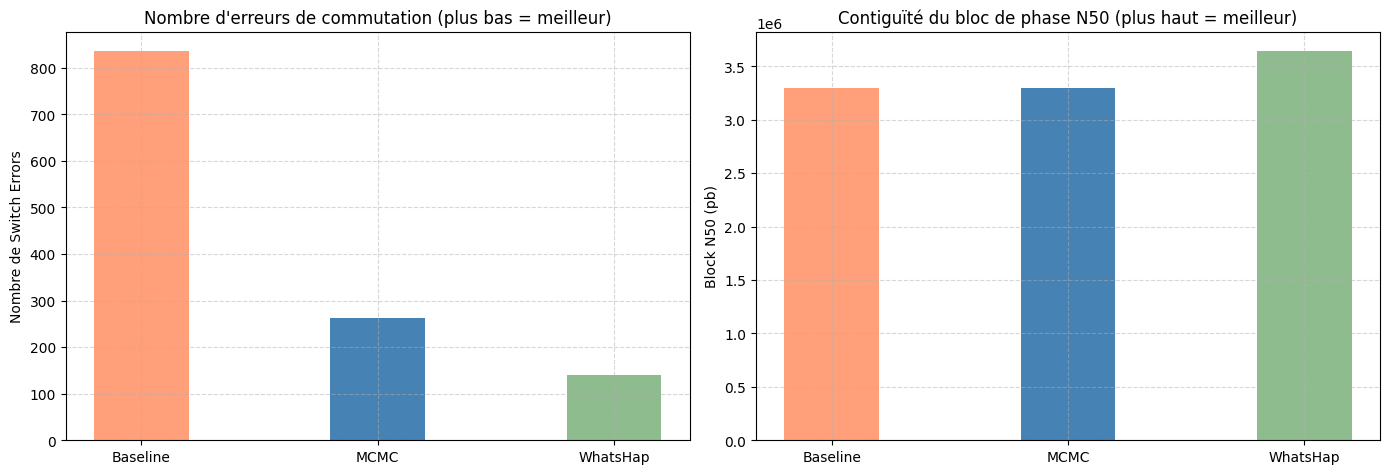

In [12]:
# @title Extraction et Affichage des Métriques Finales
def compute_block_n50(vcf_path, chromosome="chr22"):
    from collections import defaultdict
    import pysam

    blocks = defaultdict(list)
    with pysam.VariantFile(vcf_path) as vcf:
        for record in vcf:
            if record.chrom != chromosome:
                continue
            sample = list(record.samples.values())[0]
            if sample.phased and sample.get('PS') is not None:
                blocks[sample['PS']].append(record.pos)

    lengths = []
    for ps, positions in blocks.items():
        if len(positions) >= 2:
            lengths.append(max(positions) - min(positions))
        else:
            lengths.append(1)

    if not lengths:
        return 0

    lengths = sorted(lengths)
    total_len = sum(lengths)
    cum_sum = 0
    for l in lengths:
        cum_sum += l
        if cum_sum >= total_len / 2:
            return l
    return lengths[0]

def parse_whatshap_compare(filepath, vcf_path, chromosome="chr22"):
    import os
    metrics = {"switch_errors": 0, "hamming_distance": 0, "block_n50": 0, "phased_variants": 0}

    # Calculer le N50 directement et proprement depuis le VCF
    try:
        metrics["block_n50"] = compute_block_n50(vcf_path, chromosome)
    except Exception as e:
        metrics["block_n50"] = -1

    if not os.path.exists(filepath) or os.path.getsize(filepath) == 0:
        print(f"⚠️ Warning: File {filepath} not found. Running compare might have failed!")
        return metrics

    with open(filepath, "r") as f:
        in_all_blocks = False
        lines = f.readlines()
        for idx, line in enumerate(lines):
            line_lower = line.lower()

            # Nombre exact de variants couverts dans la prédiction (file1)
            if "non-singleton blocks in file1:" in line_lower:
                if idx + 1 < len(lines):
                    next_line = lines[idx+1]
                    if "covered variants" in next_line.lower():
                        parts = next_line.split()
                        for p in parts:
                            if p.replace(",", "").isdigit():
                                metrics["phased_variants"] = int(p.replace(",", ""))

            # Ne lire les erreurs que pour la section globale ALL INTERSECTION BLOCKS
            if "all intersection blocks:" in line_lower:
                in_all_blocks = True
            elif "largest intersection block:" in line_lower:
                in_all_blocks = False

            if in_all_blocks:
                if "switch errors" in line_lower:
                    parts = line.split()
                    for p in parts:
                        if p.isdigit():
                            metrics["switch_errors"] = int(p)
                elif "hamming distance" in line_lower:
                    parts = line.split()
                    for p in parts:
                        if p.isdigit():
                            metrics["hamming_distance"] = int(p)

    return metrics

print("⏳ Lecture et synthèse des résultats...")
m_baseline = parse_whatshap_compare("compare_baseline.txt", "phased_baseline.vcf", chromosome)
m_mcmc = parse_whatshap_compare("compare_mcmc.txt", "phased_mcmc.vcf", chromosome)
m_whatshap = parse_whatshap_compare("compare_whatshap.txt", "phased_whatshap.vcf", chromosome)

df_summary = pd.DataFrame([
    {"Méthode": "Baseline Spectral (original)", **m_baseline},
    {"Méthode": "MCMC k-hop Spectral", **m_mcmc},
    {"Méthode": "WhatsHap (SOTA)", **m_whatshap}
])

print("\n" + "=" * 60)
print("TABLEAU COMPARATIF DES RÉSULTATS SUR NA12878 CHR22")
print("=" * 60)
print(df_summary.to_string(index=False))

import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

methods = ["Baseline", "MCMC", "WhatsHap"]
switches = [m_baseline["switch_errors"], m_mcmc["switch_errors"], m_whatshap["switch_errors"]]
n50s = [m_baseline["block_n50"], m_mcmc["block_n50"], m_whatshap["block_n50"]]

ax1.bar(methods, switches, color=['#FFA07A', '#4682B4', '#8FBC8F'], width=0.4)
ax1.set_ylabel("Nombre de Switch Errors")
ax1.set_title("Nombre d'erreurs de commutation (plus bas = meilleur)")
ax1.grid(True, linestyle="--", alpha=0.5)

ax2.bar(methods, n50s, color=['#FFA07A', '#4682B4', '#8FBC8F'], width=0.4)
ax2.set_ylabel("Block N50 (pb)")
ax2.set_title("Contiguïté du bloc de phase N50 (plus haut = meilleur)")
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()
